In [10]:
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

In [11]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load ins 

In [12]:
df = pd.read_csv("Data/ignore/panel_data.csv")
df = df.drop("DATE", axis = 1)

df['date'] = pd.to_datetime(df["date"])

df["date"] = df["date"].dt.floor("D")

df.columns = df.columns.str.lower()

df.head()

,metro,date,regular,mid,premium,diesel,reg_delt,met,lat,lng,...,usa_rmw,usa_eye,usa_gust,usa_seahgt,storm_speed,storm_dir,distance,mid_delt,premium_delt,diesel_delt
0,Bradenton-Sarasota-Venice,2022-01-21,3.236000,3.625,3.915000,3.563000,NaN,North Port-Bradenton-Sarasota,27.3479,-82.3223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bradenton-Sarasota-Venice,2022-01-22,3.254667,3.639,3.929667,3.587667,0.576844,North Port-Bradenton-Sarasota,27.3479,-82.3223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386207,0.374628,0.692300
2,Bradenton-Sarasota-Venice,2022-01-23,3.273333,3.653,3.944333,3.612333,0.573535,North Port-Bradenton-Sarasota,27.3479,-82.3223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.384721,0.373229,0.687541
3,Bradenton-Sarasota-Venice,2022-01-24,3.292000,3.667,3.959000,3.637000,0.570265,North Port-Bradenton-Sarasota,27.3479,-82.3223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.383247,0.371841,0.682846
4,Bradenton-Sarasota-Venice,2022-01-25,3.310667,3.681,3.973667,3.661667,0.567031,North Port-Bradenton-Sarasota,27.3479,-82.3223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.381783,0.370464,0.678215


In [13]:
df.columns

Index(['metro', 'date', 'regular', 'mid', 'premium', 'diesel', 'reg_delt',
       'met', 'lat', 'lng', 'month', 'sid', 'season', 'name', 'max cat',
       'start date', 'end date', 'storm duration', 'iso_time', 'nature',
       'dist2land', 'landfall', 'usa_lat', 'usa_lon', 'usa_record',
       'usa_status', 'usa_wind', 'usa_pres', 'usa_sshs', 'usa_poci',
       'usa_roci', 'usa_rmw', 'usa_eye', 'usa_gust', 'usa_seahgt',
       'storm_speed', 'storm_dir', 'distance', 'mid_delt', 'premium_delt',
       'diesel_delt'],
      dtype='str')

In [14]:
from src.storm_regression import *

# Logitic regression for classificaition 

In [15]:
pred = ["distance", "usa_wind", "storm_speed"]

log = mod_logit(
    df = df,
    storm_name="BONNIE",
    outcome= "reg_delt",
    regressors = pred,
    threshold = 0.02
) 

print(log.summary())

Optimization terminated successfully.
         Current function value: 0.041700
         Iterations 14
                           Logit Regression Results                           
Dep. Variable:          reg_delt_bool   No. Observations:                  360
Model:                          Logit   Df Residuals:                      356
Method:                           MLE   Df Model:                            3
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.3169
Time:                        09:38:26   Log-Likelihood:                -15.012
converged:                       True   LL-Null:                       -21.977
Covariance Type:            nonrobust   LLR p-value:                  0.003002
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          32.1926     31.822      1.012      0.312     -30.177      94.562
distance       -0.2732   

# train test split 

In [19]:
len(model_df)

NameError: name 'model_df' is not defined

In [23]:
pred = ["distance", "usa_wind", "storm_speed"]

mod1, performance_df, X_train, X_test, y_train, y_test = logit_train_test(
    df=df,
    storm_name="BONNIE",
    outcome="reg_delt",
    regressors=pred,
    threshold=0.02,
    test_size=0.2
)

Rows in model_df: 360
X shape: (360, 3)
y shape: (360,)
reg_delt_bool
0    356
1      4
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.039454
         Iterations 14
                         0
observations           360
observations in train  288
observations in test    72


Confusion Matrix:
[[71  0]
 [ 1  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        71
           1       0.00      0.00      0.00         1

    accuracy                           0.99        72
   macro avg       0.49      0.50      0.50        72
weighted avg       0.97      0.99      0.98        72



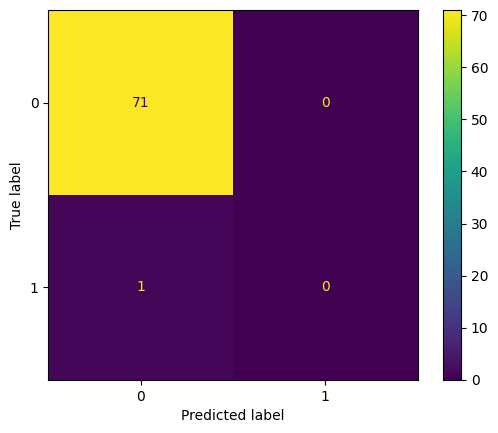

array([[71,  0],
       [ 1,  0]])

In [24]:
confusion(mod1, X_test, y_test, 
          pred_threshold= .5)